In [45]:
import pandas as pd
import numpy as np
from dataclasses import dataclass, field
from typing import List, Dict, Any, Optional, Tuple
import matplotlib.pyplot as plt
import uuid

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Load data

In [50]:
# -----------------------
# Step 1. Load Data
# -----------------------
price_df = pd.read_csv("price_path.csv", parse_dates = ["ts"])
trade_df = pd.read_csv("client_trades.csv", parse_dates = ["ts"])

price_df = price_df.sort_values("ts").reset_index(drop = True)
trade_df = trade_df.sort_values("ts").reset_index(drop = True)

print("Price rows:", len(price_df), "Trade rows:", len(trade_df))
price_df.head(), trade_df.head()

Price rows: 601 Trade rows: 223


(                         ts instrument       mid
 0 2025-09-24 08:00:00+01:00     EURUSD  1.100000
 1 2025-09-24 08:01:00+01:00     EURUSD  1.100002
 2 2025-09-24 08:02:00+01:00     EURUSD  1.099955
 3 2025-09-24 08:03:00+01:00     EURUSD  1.099855
 4 2025-09-24 08:04:00+01:00     EURUSD  1.099641,
                          ts instrument  side            qty        px  \
 0 2025-09-24 08:03:00+01:00     EURUSD     1  147883.003392  1.099855   
 1 2025-09-24 08:07:00+01:00     EURUSD     1  255942.253180  1.099665   
 2 2025-09-24 08:15:00+01:00     EURUSD     1  128833.578238  1.099711   
 3 2025-09-24 08:16:00+01:00     EURUSD    -1   68983.328924  1.099652   
 4 2025-09-24 08:21:00+01:00     EURUSD     1  148856.861329  1.099779   
 
         mid client_id  
 0  1.099855       C28  
 1  1.099665        C1  
 2  1.099711        C4  
 3  1.099652        C2  
 4  1.099779       C30  )

# Config + Event Classes 

In [64]:
# -----------------------
# Step 2. Config + Event Classes
# -----------------------
@dataclass
class BacktestConfig:
    impact_bps_per_mm: float = 0.1
    half_spread_bps: float = 0.5
    ccy1: str = "EUR"
    ccy2: str = "USD"

@dataclass
class FlowEvent:
    ts: pd.Timestamp
    side: int # +1 we buy ccy1, -1 we sell ccy1
    qty_ccy1: float # eg: notional in EUR
    px: float # execution price, eg: traded price of EURUSD
    mid: float # current mid price, eg: mid price of EURUSD
    client_id: str


# -----------------------
# Step 3. Simulator
# -----------------------
class InternalizationSimulatorFX:
    def __init__(self, cfg:BacktestConfig): 
        self.cfg = cfg
        self.state = {
            "inventory_ccy1": 0.0, # open position in ccy1
            "inventory_ccy2": 0.0, # open position in ccy2
            "last_mid": None
        }
        #self.strategy = strategy
        self.buckets: List[Dict[str, Any]] = []
        self.history: List[Dict[str, Any]] = []

    def record(self, ts, event_type, action_desc = ""):
        inv1 = self.state["inventory_ccy1"]
        inv2 = self.state["inventory_ccy2"]
        mid = self.state["last_mid"]

        # Unrealized = inventory in ccy2 converted to ccy1 
        unrealized_ccy1 = 0.0 if mid is None else inv2 / mid
        # Realized = inventory in ccy1
        realized_ccy1 = inv1
        # Total Pnl = unrealized + realized
        total_ccy1 = realized_ccy1 + unrealized_ccy1

        # also include bucket summary
        bucket_summary = [{"id": b["id"], "sign": b["sign"], "qty": b["qty_rem"], "tp": b["tp_price"], "sl": b["sl_price"]} for b in self.buckets]
        

        row = {
            "ts": ts,
            "event": event_type,
            "action": action_desc, 
            f"inventory_{self.cfg.ccy1}": inv1,
            f"inventory_{self.cfg.ccy2}": inv2,
            "realized_pnl_ccy1": realized_ccy1,
            "unrealized_pnl_ccy1": unrealized_ccy1,
            "total_pnl_ccy1": total_ccy1,
            "n_buckets": len(self.buckets),
            "buckets": bucket_summary
        }
        self.history.append(row)

    # helper to add a new bucket (for trades that add risk)
    def _add_bucket(self, ts, side, qty_ccy1, entry_px, tp_bps, sl_bps):
        # side: +1 (we bought ccy1) or -1 (we sold ccy1)
        assert side in (+1, -1)

        # compute tp/sl price in ccy2/ccy1 using bps
        # for buy(sell=+1): we need to sell, TP is higher price, SL is the lower price
        tp_price = entry_px * (1.0 + tp_bps / 1e4)
        sl_price = entry_px * (1.0 - sl_bps / 1e4)

        # for sell (side=-1): TP is lower price, SL is higher price
        if side == -1:
            tp_price = entry_px * (1.0 - tp_bps / 1e4)
            sl_price = entry_px * (1.0 + sl_bps / 1e4)
        
        bucket = {
            "id": str(uuid.uuid4())[:8],
            "created_ts": ts,
            "sign": side,
            "qty_rem": qty_ccy1,   # signed quantity from our perspective (+ = long ccy1)
            "entry_px": entry_px,
            "tp_price": tp_price,
            "sl_price": sl_price
        }
        self.buckets.append(bucket)
        return bucket

    # match incoming opposite-side qty against buckets FIFO
    def _consume_buckets(self, ts, qty_to_consume):
        # qty_to_consume is signed; typically opposite sign relative to buckets
        remaining = qty_to_consume
        actions = []
        # iterate over copy to allow removing
        for b in list(self.buckets):
            if remaining == 0:
                break
            # if same sign, skip
            if np.sign(b["qty_rem"]) == np.sign(remaining):
                continue
            # amount we can cancel from bucket (abs)
            available = abs(b["qty_rem"])
            use = min(available, abs(remaining))
            # use has sign of bucket to subtract
            use_signed = np.sign(b["qty_rem"]) * use
            # reduce bucket
            b["qty_rem"] -= use_signed
            # reduce remaining
            remaining = remaining + use_signed  # since use_signed has same sign as bucket, adding reduces opposite
            # if bucket emptied, remove
            if abs(b["qty_rem"]) < 1e-12:
                self.buckets.remove(b)
            # record action: we don't external hedge upon matching client trades; it's internalization
            actions.append({"ts": ts, "type": "consume_bucket", "bucket_id": b["id"], "consumed_qty": use_signed})
        return remaining, actions


    # Perform an external hedge: qty_ccy1 uses same sign convention (+ buy ccy1)
    def external_hedge(self, ts, qty_ccy1, mid, reason="auto_hedge"):
        if qty_ccy1 == 0:
            return None
        # execution px adjusted by impact in same direction as qty
        side = 1 if qty_ccy1 > 0 else -1
        impact = (self.cfg.impact_bps_per_mm / 1e4) * (abs(qty_ccy1) / 1e6) * mid
        exec_px = mid + side * impact
        # update inventory and cash consistently:
        # buy ccy1 (qty>0): inventory += qty, cash -= qty * px
        # sell ccy1 (qty<0): inventory += qty (decrease), cash -= qty * px (increase)
        self.state["inventory_ccy1"] += qty_ccy1
        self.state["inventory_ccy2"] -= qty_ccy1 * exec_px
        desc = f"{reason}, qty={qty_ccy1:.3f}, exec_px={exec_px:.6f}"
        self.record(ts, "external_hedge", desc)
        return {"qty": qty_ccy1, "px": exec_px, "reason": reason}



    # handle client trade (our-side sign)
    def on_client_trade(self, ev: FlowEvent, tp_bps: float, sl_bps: float):
        # update mid
        self.state["last_mid"] = ev.mid
        
        # Inventory updates
        qty = ev.side * ev.qty_ccy1
        inv2_change = -ev.side * ev.qty_ccy1 * ev.px

        self.state["inventory_ccy1"] += qty
        self.state["inventory_ccy2"] += inv2_change
        self.record(ev.ts, "client_trade", f"client_side = {-ev.side}, qty = {ev.qty_ccy1}, px={ev.px:.6f}")

        # If the trade added risk in the sign of the trade (i.e. increased abs inventory relative to prior),
        # we create a new bucket for the added portion using entry price = ev.px
        # If the trade reduces existing buckets (opposite sign), we consume FIFO and keep bucket TP/SL unchanged.
        # Simple logic: determine net change effect on inventory sign per amount.

        # Case 1: opposite-side trade reducing existing buckets
        # Determine opposite quantity relative to existing buckets: if there are buckets of opposite sign, try to consume them
        # Compute remaining qty to add as new bucket after consumption
        remaining_to_process = qty  # signed
        # If there are opposite-signed buckets, consume them
        if len(self.buckets) > 0:
            remaining_to_process_before = remaining_to_process
            remaining_to_process, consume_actions = self._consume_buckets(ev.ts, remaining_to_process)
            # record consumption actions (these are internal nettings)
            for c in consume_actions:
                self.record(ev.ts, "consume_bucket", f"bucket={c['bucket_id']}, consumed_qty={c['consumed_qty']:.6f}")

        # If after consumption there remains qty in the same direction (adds risk), create new bucket
        if remaining_to_process != 0:
            # remaining_to_process has sign of ev.side (we increased inventory in that sign)
            new_qty = remaining_to_process
            # create bucket for new_qty using client px
            b = self._add_bucket(ev.ts, int(np.sign(new_qty)), new_qty, ev.px, tp_bps, sl_bps)
            self.record(ev.ts, "create_bucket", f"id={b['id']}, sign={b['sign']}, qty={b['qty_rem']:.6f}, tp={b['tp_price']:.6f}, sl={b['sl_price']:.6f}")


    # on price tick: check buckets TP/SL
    def on_market_tick(self, ts, mid):
        self.state["last_mid"] = mid
        # check each bucket (copy to allow removing while iterating)
        fired = []
        for b in list(self.buckets):
            if b["sign"] == 0:
                continue
            # for long bucket (sign=+1):
            if b["sign"] == 1:
                if mid >= b["tp_price"]:
                    fired.append((b, "TP"))
                elif mid <= b["sl_price"]:
                    fired.append((b, "SL"))
            else:
                # short bucket (we sold ccy1): TP is lower price, SL is higher
                if mid <= b["tp_price"]:
                    fired.append((b, "TP"))
                elif mid >= b["sl_price"]:
                    fired.append((b, "SL"))

        # For each fired bucket, externalize the bucket qty (i.e., hedge to remove it)
        for b, reason in fired:
            qty_to_clear = b["qty_rem"]  # signed
            # To reduce inventory we need to execute opposite trade: external hedge qty = -qty_to_clear
            hedge_qty = -qty_to_clear
            self.external_hedge(ts, hedge_qty, mid, reason=f"bucket_{reason}")
            # remove bucket
            try:
                self.buckets.remove(b)
            except ValueError:
                pass
            self.record(ts, "bucket_fired", f"id={b['id']}, reason={reason}, cleared_qty={qty_to_clear:.6f}")

    def results_df(self):
        return pd.DataFrame(self.history)



# -----------------------
# Step 4. Strategy
# -----------------------
# Cell 4: Bucketed strategy wrapper (simple holder of thresholds)
# The simulator already contains bucket logic; the "strategy" is basically the TP/SL thresholds.
@dataclass
class BucketedTPStrategy:
    tp_bps: float = 5.0
    sl_bps: float = 8.0

    # on_event is handled by simulator's on_client_trade, so we provide simple interface
    def on_client_trade(self, ev: FlowEvent, sim: InternalizationSimulatorFX):
        sim.on_client_trade(ev, tp_bps=self.tp_bps, sl_bps=self.sl_bps)

    def on_market_tick(self, ts, mid, sim: InternalizationSimulatorFX):
        sim.on_market_tick(ts, mid)



# -----------------------
# Step 5. Run Function
# -----------------------
# Cell 5: Runner: merging price ticks and trades; single-run function
def run_simulation(price_df, trade_df, cfg: BacktestConfig, tp_bps=5.0, sl_bps=8.0, verbose=False):
    sim = InternalizationSimulatorFX(cfg)
    strat = BucketedTPStrategy(tp_bps=tp_bps, sl_bps=sl_bps)

    # create unified timeline
    # price events as ("price", ts, mid)
    # trade events as ("trade", ts, row)
    price_events = [("price", row.ts.to_pydatetime(), row.mid) for row in price_df.itertuples()]
    trade_events = [("trade", row.ts.to_pydatetime(), row) for row in trade_df.itertuples()]

    # combine and sort (if equal ts, process price first then trades so ticks are visible)
    all_events = price_events + trade_events
    all_events.sort(key=lambda x: (x[1], 0 if x[0]=="price" else 1))

    for ev_type, ts, payload in all_events:
        if ev_type == "price":
            mid = payload
            sim.on_market_tick(ts, mid)
            # optionally allow strategy-level on_market_tick (already called inside)
        else:
            row = payload
            # build FlowEvent using our sign convention: assume trade_df originally had client-side sign
            # **Important**: Ensure trade_df 'side' is in our perspective (+1 we buy ccy1, -1 we sell ccy1)
            fe = FlowEvent(ts=row.ts, side=int(row.side), qty_ccy1=float(row.qty), px=float(row.px), mid=float(row.mid), client_id=str(row.client_id))
            # record happens inside on_client_trade
            strat.on_client_trade(fe, sim)

    # finalize: last market tick record already done
    return sim



In [66]:

# -----------------------
# Step 6. Single Run
# -----------------------

# quick single run
cfg = BacktestConfig(ccy1="EUR", ccy2="USD")
sim = run_simulation(price_df, trade_df, cfg, tp_bps=5.0, sl_bps=8.0)
df = sim.results_df()
print("Total rows logged:", len(df))
df.head(40)


Total rows logged: 597


,ts,event,action,inventory_EUR,inventory_USD,realized_pnl_ccy1,unrealized_pnl_ccy1,total_pnl_ccy1,n_buckets,buckets
0,2025-09-24 08:03:00+01:00,client_trade,"client_side = -1, qty = 147883.00339214224, px...",1.478830e+05,-1.626499e+05,1.478830e+05,-1.478830e+05,0.000000,0,[]
1,2025-09-24 08:03:00+01:00,create_bucket,"id=2b9555e2, sign=1, qty=147883.003392, tp=1.1...",1.478830e+05,-1.626499e+05,1.478830e+05,-1.478830e+05,0.000000,1,"[{'id': '2b9555e2', 'sign': 1, 'qty': 147883.0..."
2,2025-09-24 08:07:00+01:00,client_trade,"client_side = -1, qty = 255942.25317959243, px...",4.038253e+05,-4.441006e+05,4.038253e+05,-4.038509e+05,-25.668521,1,"[{'id': '2b9555e2', 'sign': 1, 'qty': 147883.0..."
3,2025-09-24 08:07:00+01:00,create_bucket,"id=77f5777c, sign=1, qty=255942.253180, tp=1.1...",4.038253e+05,-4.441006e+05,4.038253e+05,-4.038509e+05,-25.668521,2,"[{'id': '2b9555e2', 'sign': 1, 'qty': 147883.0..."
4,2025-09-24 08:15:00+01:00,client_trade,"client_side = -1, qty = 128833.57823757056, px...",5.326588e+05,-5.857803e+05,5.326588e+05,-5.326674e+05,-8.566764,2,"[{'id': '2b9555e2', 'sign': 1, 'qty': 147883.0..."
5,2025-09-24 08:15:00+01:00,create_bucket,"id=df30463a, sign=1, qty=128833.578238, tp=1.1...",5.326588e+05,-5.857803e+05,5.326588e+05,-5.326674e+05,-8.566764,3,"[{'id': '2b9555e2', 'sign': 1, 'qty': 147883.0..."
6,2025-09-24 08:16:00+01:00,client_trade,"client_side = 1, qty = 68983.3289239861, px=1....",4.636755e+05,-5.099227e+05,4.636755e+05,-4.637129e+05,-37.431101,3,"[{'id': '2b9555e2', 'sign': 1, 'qty': 147883.0..."
7,2025-09-24 08:16:00+01:00,consume_bucket,"bucket=2b9555e2, consumed_qty=68983.328924",4.636755e+05,-5.099227e+05,4.636755e+05,-4.637129e+05,-37.431101,3,"[{'id': '2b9555e2', 'sign': 1, 'qty': 78899.67..."
8,2025-09-24 08:21:00+01:00,client_trade,"client_side = -1, qty = 148856.8613285905, px=...",6.125324e+05,-6.736323e+05,6.125324e+05,-6.125161e+05,16.268244,3,"[{'id': '2b9555e2', 'sign': 1, 'qty': 78899.67..."
9,2025-09-24 08:21:00+01:00,create_bucket,"id=87f38942, sign=1, qty=148856.861329, tp=1.1...",6.125324e+05,-6.736323e+05,6.125324e+05,-6.125161e+05,16.268244,4,"[{'id': '2b9555e2', 'sign': 1, 'qty': 78899.67..."


,ts,event,action,inventory_EUR,inventory_USD,realized_pnl_ccy1,unrealized_pnl_ccy1,total_pnl_ccy1,n_buckets,buckets
567,2025-09-24 17:35:00+01:00,create_bucket,"id=971c2172, sign=-1, qty=-153904.192589, tp=1...",-1.570888e+06,1.730511e+06,-1.570888e+06,1.570159e+06,-728.985801,8,"[{'id': '1cb14a6a', 'sign': -1, 'qty': -61999...."
568,2025-09-24 17:38:00+01:00,client_trade,"client_side = 1, qty = 770341.2089990119, px=1...",-2.341229e+06,2.579637e+06,-2.341229e+06,2.340288e+06,-940.993464,8,"[{'id': '1cb14a6a', 'sign': -1, 'qty': -61999...."
569,2025-09-24 17:38:00+01:00,create_bucket,"id=3aa774ed, sign=-1, qty=-770341.208999, tp=1...",-2.341229e+06,2.579637e+06,-2.341229e+06,2.340288e+06,-940.993464,9,"[{'id': '1cb14a6a', 'sign': -1, 'qty': -61999...."
570,2025-09-24 17:41:00+01:00,client_trade,"client_side = 1, qty = 134179.06025296787, px=...",-2.475408e+06,2.727558e+06,-2.475408e+06,2.474158e+06,-1250.313598,9,"[{'id': '1cb14a6a', 'sign': -1, 'qty': -61999...."
571,2025-09-24 17:41:00+01:00,create_bucket,"id=cb4658da, sign=-1, qty=-134179.060253, tp=1...",-2.475408e+06,2.727558e+06,-2.475408e+06,2.474158e+06,-1250.313598,10,"[{'id': '1cb14a6a', 'sign': -1, 'qty': -61999...."
572,2025-09-24 17:44:00+01:00,external_hedge,"bucket_SL, qty=61999.192, exec_px=1.102469",-2.413409e+06,2.659206e+06,-2.413409e+06,2.412048e+06,-1360.965781,10,"[{'id': '1cb14a6a', 'sign': -1, 'qty': -61999...."
573,2025-09-24 17:44:00+01:00,bucket_fired,"id=1cb14a6a, reason=SL, cleared_qty=-61999.191671",-2.413409e+06,2.659206e+06,-2.413409e+06,2.412048e+06,-1360.965781,9,"[{'id': '6a6d1a1d', 'sign': -1, 'qty': -121787..."
574,2025-09-24 17:44:00+01:00,external_hedge,"bucket_SL, qty=121787.820, exec_px=1.102469",-2.291621e+06,2.524939e+06,-2.291621e+06,2.290260e+06,-1361.114103,9,"[{'id': '6a6d1a1d', 'sign': -1, 'qty': -121787..."
575,2025-09-24 17:44:00+01:00,bucket_fired,"id=6a6d1a1d, reason=SL, cleared_qty=-121787.81...",-2.291621e+06,2.524939e+06,-2.291621e+06,2.290260e+06,-1361.114103,8,"[{'id': '2819b4e7', 'sign': -1, 'qty': -401197..."
576,2025-09-24 17:44:00+01:00,client_trade,"client_side = 1, qty = 352376.0398117444, px=1...",-2.643998e+06,2.913422e+06,-2.643998e+06,2.642636e+06,-1361.114103,8,"[{'id': '2819b4e7', 'sign': -1, 'qty': -401197..."


Final PnL (ccy1): -275.2009816634236
Inventory (ccy1): -906128.7777128764
Cash (ccy2): 998109.5228235435


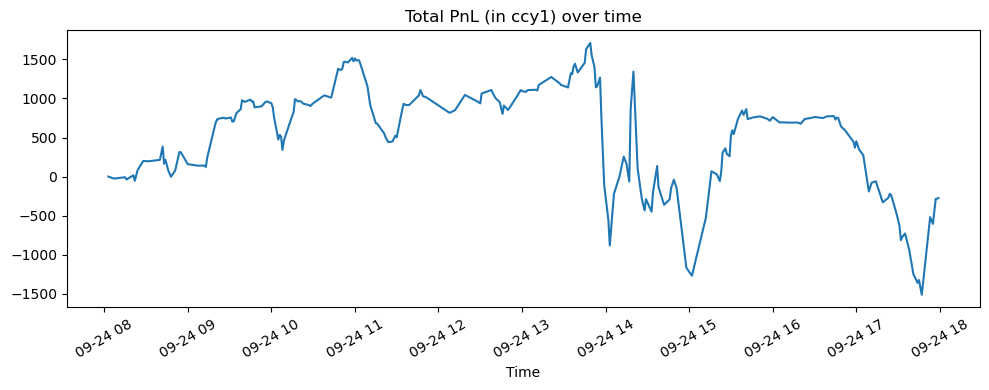

In [70]:
# Cell 6: Inspect and visualize results
# show last lines and summarize final PnL
display(df.tail(30))

final_row = df.iloc[-1]
print("Final PnL (ccy1):", final_row["total_pnl_ccy1"])
print("Inventory (ccy1):", final_row[f"inventory_{cfg.ccy1}"])
print("Cash (ccy2):", final_row[f"inventory_{cfg.ccy2}"])

# Plot PnL path in ccy1
plt.figure(figsize=(10,4))
plt.plot(df['ts'], df['total_pnl_ccy1'])
plt.title("Total PnL (in ccy1) over time")
plt.xlabel("Time")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


,tp_bps,sl_bps,final_pnl_ccy1
0,2.5,5,-545.449064
1,2.5,8,-351.730246
2,2.5,12,-284.821500
3,5.0,5,555.437861
4,5.0,8,-275.200982
5,5.0,12,-40.360478
6,10.0,5,1445.468953
7,10.0,8,-2598.796131
8,10.0,12,-3865.644065


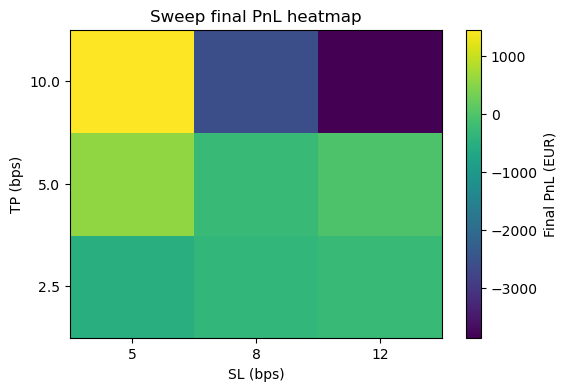

In [72]:
# Cell 7: Parameter sweep (optional)
def sweep_tp_sl(price_df, trade_df, cfg, tp_list, sl_list):
    records = []
    for tp in tp_list:
        for sl in sl_list:
            sim = run_simulation(price_df, trade_df, cfg, tp_bps=tp, sl_bps=sl)
            res = sim.results_df()
            final = res.iloc[-1]["total_pnl_ccy1"]
            records.append({"tp_bps": tp, "sl_bps": sl, "final_pnl_ccy1": final})
    return pd.DataFrame(records)

tp_values = [2.5, 5, 10]
sl_values = [5, 8, 12]
sweep_df = sweep_tp_sl(price_df, trade_df, cfg, tp_values, sl_values)
display(sweep_df)

# Heatmap display
pivot = sweep_df.pivot(index='tp_bps', columns='sl_bps', values='final_pnl_ccy1')
plt.figure(figsize=(6,4))
plt.imshow(pivot, origin='lower', aspect='auto')
plt.colorbar(label=f"Final PnL ({cfg.ccy1})")
plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.xlabel("SL (bps)")
plt.ylabel("TP (bps)")
plt.title("Sweep final PnL heatmap")
plt.show()
